Using device: cuda


Training Progress: 100%|██████████| 20000/20000 [00:44<00:00, 453.62it/s]
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following 

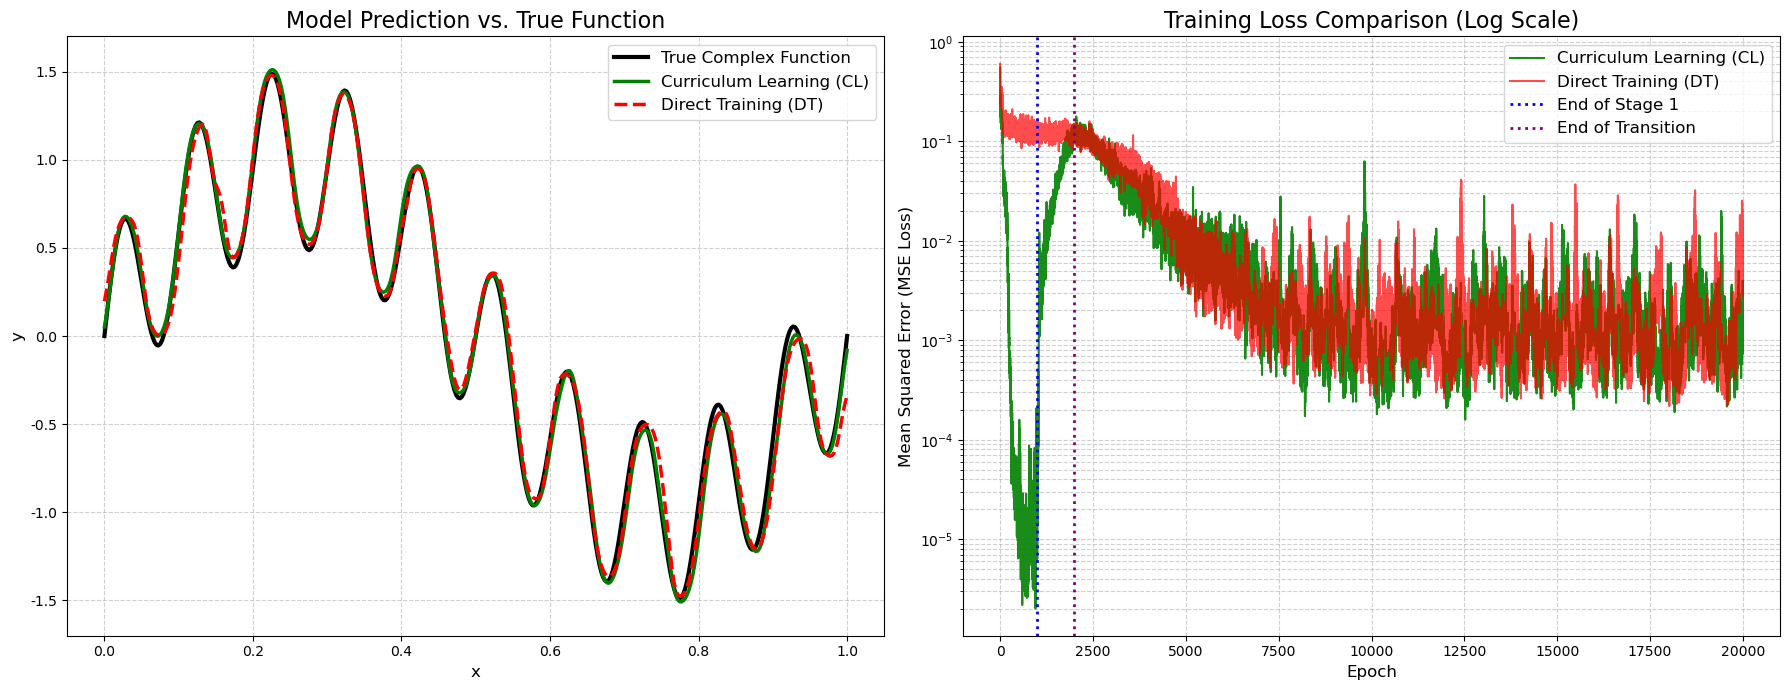


Training Complete!
Final Curriculum Learning Loss (CL): 0.003148
Final Direct Training Loss (DT): 0.009864


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # For a nice progress bar
import copy

# --- 1. Hyperparameters & Configuration ---
LEARNING_RATE = 0.005
BATCH_SIZE = 64
TOTAL_EPOCHS = 20000

# Curriculum Learning Stage Definitions
STAGE1_END = 1000  # Epoch where the simple task ends
STAGE2_END = 2000  # Epoch where the transition phase ends

# Check for available GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


# --- 2. Target Function Definitions ---
def f_simple(x):
    """Simple function: a low-frequency sine wave."""
    return np.sin(2 * np.pi * x)

def f_complex(x):
    """Complex function: a sum of low and high-frequency waves."""
    return np.sin(2 * np.pi * x) + 0.5 * np.sin(20 * np.pi * x)


# --- 3. Neural Network Definition ---
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        # This is the deeper network structure from your provided code
        self.layers = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.layers(x)


# --- 4. Model and Optimizer Initialization ---
# Curriculum Learning Model
cl_model = NeuralNetwork().to(DEVICE)
# Direct Training Model
dt_model = NeuralNetwork().to(DEVICE)

# Crucial step: ensure both models have identical initial weights for a fair comparison
dt_model.load_state_dict(copy.deepcopy(cl_model.state_dict()))

# Loss Function
criterion = nn.MSELoss()

# Optimizers
cl_optimizer = optim.Adam(cl_model.parameters(), lr=LEARNING_RATE)
dt_optimizer = optim.Adam(dt_model.parameters(), lr=LEARNING_RATE)


# --- 5. Training Loop ---
cl_losses = []
dt_losses = []

# Use tqdm for a progress bar
for epoch in tqdm(range(TOTAL_EPOCHS), desc="Training Progress"):
    # --- Curriculum Learning (CL) Training Step ---
    cl_model.train()
    
    # Determine the current curriculum mixing factor 'alpha'
    if epoch < STAGE1_END:
        alpha = 0.0
    elif epoch < STAGE2_END:
        # In the transition phase, alpha increases linearly from 0 to 1
        alpha = (epoch - STAGE1_END) / (STAGE2_END - STAGE1_END)
    else:
        alpha = 1.0

    # Generate a batch of data
    x_train = torch.rand(BATCH_SIZE, 1).to(DEVICE)
    
    # Calculate the target 'y' for CL based on alpha
    y_simple_tensor = torch.tensor(f_simple(x_train.cpu().numpy()), dtype=torch.float32).to(DEVICE)
    y_complex_tensor = torch.tensor(f_complex(x_train.cpu().numpy()), dtype=torch.float32).to(DEVICE)
    y_true_cl = (1 - alpha) * y_simple_tensor + alpha * y_complex_tensor

    # Forward pass, compute loss, backward pass, update weights
    cl_optimizer.zero_grad()
    cl_output = cl_model(x_train)
    cl_loss = criterion(cl_output, y_true_cl)
    cl_loss.backward()
    cl_optimizer.step()
    
    # Record the loss (use .item() to get the scalar value from the tensor)
    cl_losses.append(cl_loss.item())

    # --- Direct Training (DT) Training Step ---
    dt_model.train()
    
    # Use the same batch of x_train for a fair comparison
    y_true_dt = torch.tensor(f_complex(x_train.cpu().numpy()), dtype=torch.float32).to(DEVICE)

    # Forward pass, compute loss, backward pass, update weights
    dt_optimizer.zero_grad()
    dt_output = dt_model(x_train)
    dt_loss = criterion(dt_output, y_true_dt)
    dt_loss.backward()
    dt_optimizer.step()
    
    dt_losses.append(dt_loss.item())


# --- 6. Visualization ---

# Create a range of x-values for plotting
x_plot = np.linspace(0, 1, 400)
x_plot_tensor = torch.tensor(x_plot, dtype=torch.float32).view(-1, 1).to(DEVICE)

# Set models to evaluation mode
cl_model.eval()
dt_model.eval()

# Get model predictions
with torch.no_grad(): # No need to calculate gradients during evaluation
    y_pred_cl = cl_model(x_plot_tensor).cpu().numpy()
    y_pred_dt = dt_model(x_plot_tensor).cpu().numpy()

# Get the true function values
y_true_complex = f_complex(x_plot)

# Create a 1x2 subplot layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot 1: Model Prediction vs. True Function ---
ax1.plot(x_plot, y_true_complex, 'k-', linewidth=3, label='True Complex Function')
ax1.plot(x_plot, y_pred_cl, 'g-', linewidth=2.5, label='Curriculum Learning (CL)')
ax1.plot(x_plot, y_pred_dt, 'r--', linewidth=2.5, label='Direct Training (DT)')
ax1.set_title('Model Prediction vs. True Function', fontsize=16)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_ylim(-1.7, 1.7)

# --- Subplot 2: Training Loss Comparison ---
epochs_range = range(TOTAL_EPOCHS)
ax2.plot(epochs_range, cl_losses, 'g-', linewidth=1.5, label='Curriculum Learning (CL)', alpha=0.9)
ax2.plot(epochs_range, dt_losses, 'r-', linewidth=1.5, label='Direct Training (DT)', alpha=0.7)
ax2.set_yscale('log') # Set y-axis to log scale
ax2.set_title('Training Loss Comparison (Log Scale)', fontsize=16)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Mean Squared Error (MSE Loss)', fontsize=12)
ax2.grid(True, which="both", linestyle='--', alpha=0.6)

# Add vertical lines to indicate curriculum stages
ax2.axvline(x=STAGE1_END, color='blue', linestyle=':', linewidth=2, label='End of Stage 1')
ax2.axvline(x=STAGE2_END, color='purple', linestyle=':', linewidth=2, label='End of Transition')
ax2.legend(fontsize=12) # Re-call legend to show the new labels

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Print the final loss values
print(f"\nTraining Complete!")
print(f"Final Curriculum Learning Loss (CL): {cl_losses[-1]:.6f}")
print(f"Final Direct Training Loss (DT): {dt_losses[-1]:.6f}")

Using device: cuda


Training Progress: 100%|██████████| 20000/20000 [00:46<00:00, 432.74it/s]
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following 

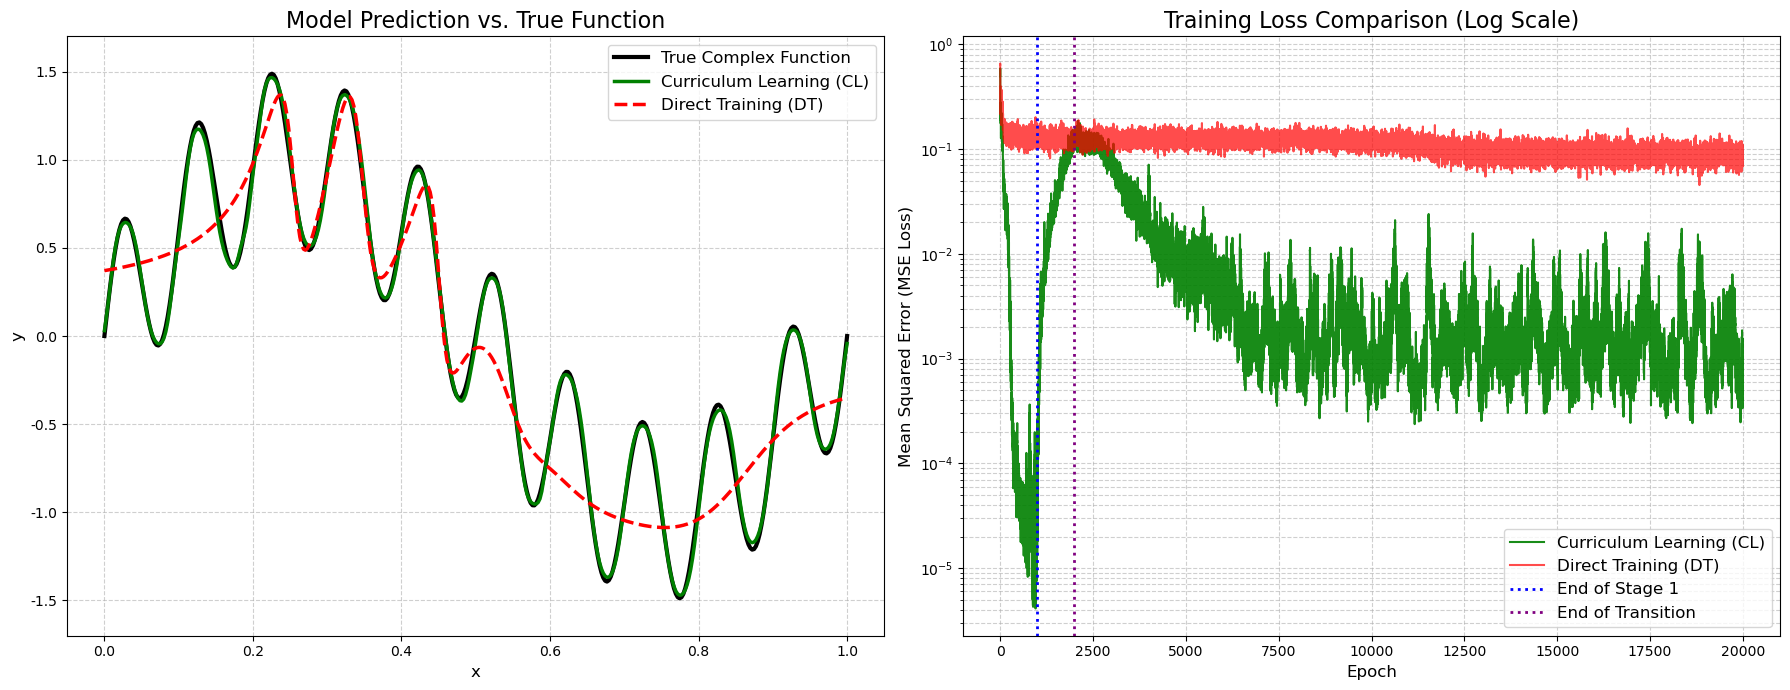


Training Complete!
Final Curriculum Learning Loss (CL): 0.000341
Final Direct Training Loss (DT): 0.083223


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # For a nice progress bar
import copy

# --- 1. Hyperparameters & Configuration ---
LEARNING_RATE = 0.005
BATCH_SIZE = 64
TOTAL_EPOCHS = 20000

# Curriculum Learning Stage Definitions
STAGE1_END = 1000  # Epoch where the simple task ends
STAGE2_END = 2000  # Epoch where the transition phase ends

# Check for available GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


# --- 2. Target Function Definitions ---
def f_simple(x):
    """Simple function: a low-frequency sine wave."""
    return np.sin(2 * np.pi * x)

def f_complex(x):
    """Complex function: a sum of low and high-frequency waves."""
    return np.sin(2 * np.pi * x) + 0.5 * np.sin(20 * np.pi * x)


# --- 3. Neural Network Definition ---
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        # This is the deeper network structure from your provided code
        self.layers = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.layers(x)


# --- 4. Model and Optimizer Initialization ---
# Curriculum Learning Model
cl_model = NeuralNetwork().to(DEVICE)
# Direct Training Model
dt_model = NeuralNetwork().to(DEVICE)

# Crucial step: ensure both models have identical initial weights for a fair comparison
dt_model.load_state_dict(copy.deepcopy(cl_model.state_dict()))

# Loss Function
criterion = nn.MSELoss()

# Optimizers
cl_optimizer = optim.Adam(cl_model.parameters(), lr=LEARNING_RATE)
dt_optimizer = optim.Adam(dt_model.parameters(), lr=LEARNING_RATE)


# --- 5. Training Loop ---
cl_losses = []
dt_losses = []

# Use tqdm for a progress bar
for epoch in tqdm(range(TOTAL_EPOCHS), desc="Training Progress"):
    # --- Curriculum Learning (CL) Training Step ---
    cl_model.train()
    
    # Determine the current curriculum mixing factor 'alpha'
    if epoch < STAGE1_END:
        alpha = 0.0
    elif epoch < STAGE2_END:
        # In the transition phase, alpha increases linearly from 0 to 1
        alpha = (epoch - STAGE1_END) / (STAGE2_END - STAGE1_END)
    else:
        alpha = 1.0

    # Generate a batch of data
    x_train = torch.rand(BATCH_SIZE, 1).to(DEVICE)
    
    # Calculate the target 'y' for CL based on alpha
    y_simple_tensor = torch.tensor(f_simple(x_train.cpu().numpy()), dtype=torch.float32).to(DEVICE)
    y_complex_tensor = torch.tensor(f_complex(x_train.cpu().numpy()), dtype=torch.float32).to(DEVICE)
    y_true_cl = (1 - alpha) * y_simple_tensor + alpha * y_complex_tensor

    # Forward pass, compute loss, backward pass, update weights
    cl_optimizer.zero_grad()
    cl_output = cl_model(x_train)
    cl_loss = criterion(cl_output, y_true_cl)
    cl_loss.backward()
    cl_optimizer.step()
    
    # Record the loss (use .item() to get the scalar value from the tensor)
    cl_losses.append(cl_loss.item())

    # --- Direct Training (DT) Training Step ---
    dt_model.train()
    
    # Use the same batch of x_train for a fair comparison
    y_true_dt = torch.tensor(f_complex(x_train.cpu().numpy()), dtype=torch.float32).to(DEVICE)

    # Forward pass, compute loss, backward pass, update weights
    dt_optimizer.zero_grad()
    dt_output = dt_model(x_train)
    dt_loss = criterion(dt_output, y_true_dt)
    dt_loss.backward()
    dt_optimizer.step()
    
    dt_losses.append(dt_loss.item())


# --- 6. Visualization ---

# Create a range of x-values for plotting
x_plot = np.linspace(0, 1, 400)
x_plot_tensor = torch.tensor(x_plot, dtype=torch.float32).view(-1, 1).to(DEVICE)

# Set models to evaluation mode
cl_model.eval()
dt_model.eval()

# Get model predictions
with torch.no_grad(): # No need to calculate gradients during evaluation
    y_pred_cl = cl_model(x_plot_tensor).cpu().numpy()
    y_pred_dt = dt_model(x_plot_tensor).cpu().numpy()

# Get the true function values
y_true_complex = f_complex(x_plot)

# Create a 1x2 subplot layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot 1: Model Prediction vs. True Function ---
ax1.plot(x_plot, y_true_complex, 'k-', linewidth=3, label='True Complex Function')
ax1.plot(x_plot, y_pred_cl, 'g-', linewidth=2.5, label='Curriculum Learning (CL)')
ax1.plot(x_plot, y_pred_dt, 'r--', linewidth=2.5, label='Direct Training (DT)')
ax1.set_title('Model Prediction vs. True Function', fontsize=16)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_ylim(-1.7, 1.7)

# --- Subplot 2: Training Loss Comparison ---
epochs_range = range(TOTAL_EPOCHS)
ax2.plot(epochs_range, cl_losses, 'g-', linewidth=1.5, label='Curriculum Learning (CL)', alpha=0.9)
ax2.plot(epochs_range, dt_losses, 'r-', linewidth=1.5, label='Direct Training (DT)', alpha=0.7)
ax2.set_yscale('log') # Set y-axis to log scale
ax2.set_title('Training Loss Comparison (Log Scale)', fontsize=16)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Mean Squared Error (MSE Loss)', fontsize=12)
ax2.grid(True, which="both", linestyle='--', alpha=0.6)

# Add vertical lines to indicate curriculum stages
ax2.axvline(x=STAGE1_END, color='blue', linestyle=':', linewidth=2, label='End of Stage 1')
ax2.axvline(x=STAGE2_END, color='purple', linestyle=':', linewidth=2, label='End of Transition')
ax2.legend(fontsize=12) # Re-call legend to show the new labels

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Print the final loss values
print(f"\nTraining Complete!")
print(f"Final Curriculum Learning Loss (CL): {cl_losses[-1]:.6f}")
print(f"Final Direct Training Loss (DT): {dt_losses[-1]:.6f}")